# Modelling Notebook
## European Housing Price Forecasting — EU-27 Panel

**Course:** Machine Learning and Deep Learning, CBS Spring 2026

**Structure of this notebook:**

| Phase | Models | Data |
|---|---|---|
| 1 — Benchmarks | Naive persistence, Rolling mean, OLS | Pooled (all countries) |
| 2 — ML models | Ridge, Lasso, Random Forest, Gradient Boosting | Pooled (all countries) |
| 3 — K-Means stratified | Same ML models as Phase 2 | Within each K-Means cluster |
| 4 — Literature stratified | Same ML models as Phase 2 | Within each literature cluster |

**Key design decisions from EDA and clustering:**
- Train/test split: `year < 2022` (train=1,340 rows, test=364 rows)
- Validation: walk-forward expanding-window CV within training set only
- Feature set: all lag features + structural variables; `lt_interest_rate` as universal rate proxy
- Outlier strategy: keep all observations (economically real events)
- Clustering: K-Means (4 clusters) and literature scheme (West/North/South/East)
- DBSCAN found only 1 cluster — reported as a finding, not used for stratification

**Output:** `predictions.csv` — all model predictions aligned to (country_code, quarter, y_true)
This file is the sole input to `metrics.ipynb`.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.color': '#e8e8e8', 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'axes.titlesize': 12, 'axes.labelsize': 10,
})
ACCENT = '#2E5496'
RED    = '#C0392B'
GREEN  = '#1A7A4A'

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_excel(r'C:\Users\carla\CBS\ml-final-project\s3-clustering\model_data_clustered.xlsx')
df = df.sort_values(['country_code','quarter']).reset_index(drop=True)

print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Clusters present: cluster_data={df["cluster_data"].nunique()}, '
      f'cluster_literature={df["cluster_literature"].nunique()}')
print(f'Quarter range: {df["quarter"].min()} -> {df["quarter"].max()}')
print(f'Target (mean/std): {df["target_hpi_next_q"].mean():.3f} / {df["target_hpi_next_q"].std():.3f}')


Loaded: 1704 rows x 42 columns
Clusters present: cluster_data=4, cluster_literature=4
Quarter range: 2005-Q3 -> 2025-Q2
Target (mean/std): 1.035 / 2.222


## 1. Feature Set and Train/Test Split

### Feature set rationale

We use the full lag feature set agreed in the EDA pre-modelling checklist. `lt_interest_rate` serves as the universal interest rate proxy (covers all 26 countries). `mortgage_rate_pct` is excluded from the pooled feature set due to 33% structural missingness (non-eurozone countries). `parliament_rile` is included — it loaded strongly on PC2 in the clustering analysis, confirming it carries structural information.

### Walk-forward cross-validation

Because this is a time series panel, we cannot use random k-fold CV — that would leak future information into the past. We use **walk-forward (expanding window) CV** implemented via `TimeSeriesSplit`. Each fold expands the training window by one step and validates on the next period. This respects temporal ordering and simulates realistic forecasting conditions.

```
|--- Train fold 1 ---|  Val fold 1  |
|--- Train fold 2 --------|  Val fold 2  |
|--- Train fold 3 -------------|  Val fold 3  |
                                              | TEST (year >= 2022) |
```

The test set is never touched during training or CV — only at final evaluation in `metrics.ipynb`.


In [2]:
# ── Feature columns ─────────────────────────────────────────────────────────
FEATURES = [
    # Autoregressive HPI lags (strongest signal from EDA: r=0.30-0.34)
    'hpi_qoq_pct_lag1', 'hpi_qoq_pct_lag2',
    # Macroeconomic lags
    'gdp_qoq_pct_lag1', 'gdp_qoq_pct_lag2',
    'hicp_qoq_pct_lag1', 'hicp_qoq_pct_lag2',
    'unemployment_rate_lag1', 'unemployment_rate_lag2',
    'unemployment_qoq_change',
    # Supply side
    'permits_qoq_pct_lag1', 'permits_qoq_pct_lag2',
    # Interest rates (strongest predictor group from EDA: r=0.30-0.32)
    'lt_interest_rate', 'lt_interest_rate_lag1', 'lt_interest_rate_lag2',
    # Institutional
    'eurozone_member_timevarying',
    'parliament_rile', 'parliament_rile_lag1',
]
# Keep only features that actually exist in the dataframe
FEATURES = [f for f in FEATURES if f in df.columns]
TARGET   = 'target_hpi_next_q'

print(f'Features used ({len(FEATURES)}):')
for f in FEATURES:
    print(f'  {f}')

# ── Train / test split at 2022 (agreed in EDA Section 8) ────────────────────
SPLIT_YEAR = 2022
train_df = df[df['year'] < SPLIT_YEAR].dropna(subset=FEATURES + [TARGET]).copy()
test_df  = df[df['year'] >= SPLIT_YEAR].dropna(subset=FEATURES + [TARGET]).copy()

print(f'\nTrain: {len(train_df)} rows ({train_df["quarter"].min()} -> {train_df["quarter"].max()})')
print(f'Test:  {len(test_df)} rows ({test_df["quarter"].min()} -> {test_df["quarter"].max()})')
print(f'Test fraction: {len(test_df)/(len(train_df)+len(test_df))*100:.1f}%')


Features used (17):
  hpi_qoq_pct_lag1
  hpi_qoq_pct_lag2
  gdp_qoq_pct_lag1
  gdp_qoq_pct_lag2
  hicp_qoq_pct_lag1
  hicp_qoq_pct_lag2
  unemployment_rate_lag1
  unemployment_rate_lag2
  unemployment_qoq_change
  permits_qoq_pct_lag1
  permits_qoq_pct_lag2
  lt_interest_rate
  lt_interest_rate_lag1
  lt_interest_rate_lag2
  eurozone_member_timevarying
  parliament_rile
  parliament_rile_lag1

Train: 1199 rows (2006-Q4 -> 2021-Q4)
Test:  364 rows (2022-Q1 -> 2025-Q2)
Test fraction: 23.3%


In [3]:
# ── Initialise predictions dataframe ────────────────────────────────────────
# All model predictions will be stored here, aligned by index.
# At the end we save this as predictions.csv for metrics.ipynb.
preds = test_df[['country_code','country','quarter','year',
                  'cluster_data','cluster_literature', TARGET]].copy()
preds = preds.rename(columns={TARGET: 'y_true'})

print('Predictions container initialised:')
print(preds.shape)
print(preds.head(3))


Predictions container initialised:
(364, 7)
   country_code  country  quarter  year  cluster_data cluster_literature  \
46           AT  Austria  2022-Q1  2022             2               West   
47           AT  Austria  2022-Q2  2022             2               West   
48           AT  Austria  2022-Q3  2022             2               West   

      y_true  
46  2.915629  
47  2.455291  
48 -4.188029  


## 2. Helper Functions

We define reusable functions for training and evaluating models. Having these as functions means the same code runs for pooled, K-Means stratified, and literature stratified models — reducing repetition and ensuring consistency.


In [4]:
# ── Walk-forward CV scorer ───────────────────────────────────────────────────
def walk_forward_cv(model, X_train, y_train, n_splits=5):
    '''
    Evaluate a model using walk-forward (expanding window) cross-validation.
    Returns mean RMSE across folds.
    n_splits=5 means 5 expanding windows within the training set.
    '''
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_rmses = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_val)
        rmse  = np.sqrt(mean_squared_error(y_val, y_hat))
        fold_rmses.append(rmse)
    return np.mean(fold_rmses), np.std(fold_rmses)

# ── Train on full training set and predict on test set ───────────────────────
def train_and_predict(model, train_sub, test_sub, features=FEATURES):
    '''
    Fit model on train_sub, predict on test_sub.
    Returns array of predictions aligned to test_sub index.
    For sub-datasets (cluster-stratified), test_sub may be smaller.
    '''
    X_tr = train_sub[features].values
    y_tr = train_sub[TARGET].values
    X_te = test_sub[features].values
    model.fit(X_tr, y_tr)
    return model.predict(X_te)

# ── Quick metrics printer ────────────────────────────────────────────────────
def print_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<35} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')
    return rmse, mae, r2

print('Helper functions defined.')
print('  walk_forward_cv() -- expanding window CV, returns mean+std RMSE')
print('  train_and_predict() -- fit on train, return test predictions')
print('  print_metrics() -- RMSE / MAE / R2 for any prediction array')


Helper functions defined.
  walk_forward_cv() -- expanding window CV, returns mean+std RMSE
  train_and_predict() -- fit on train, return test predictions
  print_metrics() -- RMSE / MAE / R2 for any prediction array


## Phase 1 — Benchmark Models (Pooled)

Benchmarks establish the performance floor. A machine learning model that cannot beat these simple rules is not adding value.

**Three benchmarks:**

**1. Naive persistence** — predict that next quarter's growth equals this quarter's growth. This is the simplest possible model. Given the strong lag-1 autocorrelation of 0.632 found in EDA Section 7, this is actually a reasonable predictor and will be hard to beat.

**2. Rolling mean** — predict the 4-quarter (1-year) rolling average of past HPI growth. This smooths out noise and captures the medium-term trend. The 4-quarter window was chosen because the EDA found significant autocorrelation at lag-4 (0.548), suggesting a seasonal cycle.

**3. OLS Linear Regression** — ordinary least squares regression on the full feature set. No regularisation. This is the simplest parametric model and sets the benchmark for what adding ML complexity actually buys us.

Note: Naive persistence and rolling mean do not require a train/test split — they are rule-based. We compute them directly on the test set using lagged values.


In [5]:
# ── Benchmark 1: Naive persistence ──────────────────────────────────────────
# Predict y_t+1 = y_t (current quarter's HPI growth)
# hpi_qoq_pct_lag1 in the test set IS the current quarter's growth
# (because the target is next quarter, lag1 is the most recent observation)
naive_preds = test_df['hpi_qoq_pct_lag1'].values
preds['naive_persistence'] = naive_preds

print('=== PHASE 1: BENCHMARKS ===')
print()
rmse_naive, mae_naive, r2_naive = print_metrics(
    'Naive persistence', preds['y_true'], preds['naive_persistence'])


=== PHASE 1: BENCHMARKS ===

  Naive persistence                   RMSE=2.6286  MAE=1.9946  R2=-0.4373


In [7]:
# ── Benchmark 2: Rolling mean (4-quarter window) ─────────────────────────────
df_sorted = df.sort_values(['country_code','quarter']).copy()

df_sorted['rolling_mean_4q'] = (
    df_sorted.groupby('country_code')['hpi_qoq_pct']
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=2).mean())
)

# Merge onto test set using country_code + quarter as keys
roll_lookup = (df_sorted[['country_code','quarter','rolling_mean_4q']]
               .drop_duplicates(subset=['country_code','quarter']))

test_with_roll = test_df[['country_code','quarter']].merge(
    roll_lookup, on=['country_code','quarter'], how='left')

# Fill any remaining NaN with that country's mean from the training set
country_means = train_df.groupby('country_code')['hpi_qoq_pct'].mean()
test_with_roll['rolling_mean_4q'] = test_with_roll.apply(
    lambda r: country_means.get(r['country_code'], 0)
    if pd.isna(r['rolling_mean_4q']) else r['rolling_mean_4q'], axis=1)

preds['rolling_mean'] = test_with_roll['rolling_mean_4q'].values

rmse_roll, mae_roll, r2_roll = print_metrics(
    'Rolling mean (4q)', preds['y_true'], preds['rolling_mean'])

  Rolling mean (4q)                   RMSE=2.3309  MAE=1.7390  R2=-0.1301


In [8]:
# ── Benchmark 3: OLS Linear Regression ──────────────────────────────────────
# Standard ordinary least squares on the full feature set.
# No regularisation, no scaling needed for OLS itself but we scale for
# comparability with Ridge/Lasso later.

ols_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

X_train_all = train_df[FEATURES].values
y_train_all = train_df[TARGET].values
X_test_all  = test_df[FEATURES].values
y_test_all  = test_df[TARGET].values

# Walk-forward CV score
cv_rmse, cv_std = walk_forward_cv(
    Pipeline([('scaler',StandardScaler()),('model',LinearRegression())]),
    X_train_all, y_train_all
)
print(f'OLS walk-forward CV RMSE: {cv_rmse:.4f} +/- {cv_std:.4f}')

# Train on full train set, predict test
ols_pipeline.fit(X_train_all, y_train_all)
preds['ols'] = ols_pipeline.predict(X_test_all)

rmse_ols, mae_ols, r2_ols = print_metrics(
    'OLS linear regression', preds['y_true'], preds['ols'])

# OLS coefficients -- which features matter most?
coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': ols_pipeline.named_steps['model'].coef_
}).sort_values('coefficient', key=abs, ascending=False)
print('\nOLS top 10 coefficients (absolute magnitude):')
print(coef_df.head(10).to_string(index=False))


OLS walk-forward CV RMSE: 2.0018 +/- 0.1829
  OLS linear regression               RMSE=2.3665  MAE=1.8194  R2=-0.1649

OLS top 10 coefficients (absolute magnitude):
                    feature  coefficient
           lt_interest_rate    -0.732017
     unemployment_rate_lag1    -0.430962
          hicp_qoq_pct_lag2    -0.379027
           hpi_qoq_pct_lag2     0.296314
      lt_interest_rate_lag1     0.254200
          hicp_qoq_pct_lag1    -0.253425
eurozone_member_timevarying    -0.191521
           hpi_qoq_pct_lag1     0.176225
     unemployment_rate_lag2     0.169036
           gdp_qoq_pct_lag1     0.165415


=== PHASE 1 SUMMARY ===

  Naive persistence                   RMSE=2.6286  MAE=1.9946  R2=-0.4373
  Rolling mean (4q)                   RMSE=2.3309  MAE=1.7390  R2=-0.1301
  OLS regression                      RMSE=2.3665  MAE=1.8194  R2=-0.1649


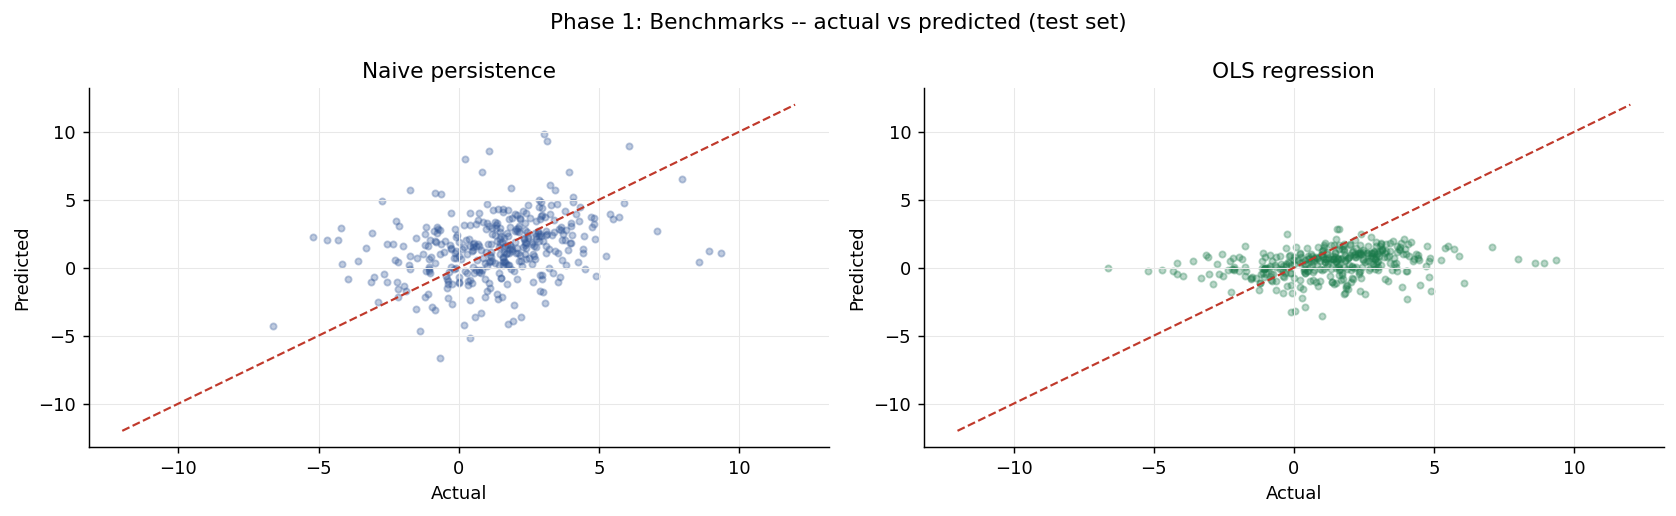

In [9]:
# ── Phase 1 summary ──────────────────────────────────────────────────────────
print('=== PHASE 1 SUMMARY ===')
print()
benchmarks = {
    'Naive persistence':  (preds['y_true'], preds['naive_persistence']),
    'Rolling mean (4q)':  (preds['y_true'], preds['rolling_mean']),
    'OLS regression':     (preds['y_true'], preds['ols']),
}
for name, (yt, yp) in benchmarks.items():
    print_metrics(name, yt, yp)

# Visual: actual vs predicted for OLS
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(preds['y_true'], preds['naive_persistence'],
                alpha=0.3, s=12, color=ACCENT)
axes[0].plot([-12,12],[-12,12], color=RED, linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Naive persistence')

axes[1].scatter(preds['y_true'], preds['ols'],
                alpha=0.3, s=12, color=GREEN)
axes[1].plot([-12,12],[-12,12], color=RED, linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('OLS regression')

plt.suptitle('Phase 1: Benchmarks -- actual vs predicted (test set)', fontsize=12)
plt.tight_layout()
plt.show()


## Phase 2 — ML Models (Pooled)

We now train four ML models on the full pooled dataset. Each model is evaluated using walk-forward CV on the training set to tune hyperparameters, then trained on the full training set and evaluated on the held-out test set.

**Ridge Regression** adds L2 regularisation to OLS, shrinking coefficients toward zero without eliminating them. Useful when features are mildly correlated (as in our case — EDA found `mortgage_rate_pct` and `lt_interest_rate` at r=0.665). *Geron (2022), Ch. 4.*

**Lasso Regression** adds L1 regularisation, which drives some coefficients exactly to zero — effectively performing feature selection. If some of our 17 features are irrelevant, Lasso will discard them automatically. *Geron (2022), Ch. 4.*

**Random Forest** builds many decision trees on bootstrapped subsamples and averages their predictions. Handles non-linearity and interactions automatically. Robust to outliers. *Geron (2022), Ch. 7.*

**Gradient Boosting** builds trees sequentially, each correcting the errors of the previous. Often the strongest off-the-shelf model for tabular data. *Geron (2022), Ch. 7.*

**Hyperparameter tuning:** We use a small manual grid evaluated via walk-forward CV. The best alpha (Ridge/Lasso) and key tree parameters are selected based on CV RMSE.


In [10]:
# ── Phase 2.1: Ridge Regression ──────────────────────────────────────────────
from sklearn.linear_model import RidgeCV

print('=== RIDGE REGRESSION ===')
# RidgeCV uses efficient leave-one-out CV internally to select alpha
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RidgeCV(alphas=alphas, cv=5, scoring='neg_root_mean_squared_error'))
])

# Walk-forward CV
cv_rmse, cv_std = walk_forward_cv(
    Pipeline([('scaler',StandardScaler()),
              ('model',RidgeCV(alphas=alphas))]),
    X_train_all, y_train_all
)
print(f'  Walk-forward CV RMSE: {cv_rmse:.4f} +/- {cv_std:.4f}')

# Train on full train, predict test
ridge_cv.fit(X_train_all, y_train_all)
preds['ridge'] = ridge_cv.predict(X_test_all)
best_alpha = ridge_cv.named_steps['model'].alpha_
print(f'  Best alpha selected: {best_alpha}')

print_metrics('Ridge', preds['y_true'], preds['ridge'])


=== RIDGE REGRESSION ===
  Walk-forward CV RMSE: 1.9653 +/- 0.1713
  Best alpha selected: 100.0
  Ridge                               RMSE=2.3104  MAE=1.7749  R2=-0.1104


(np.float64(2.310423275227072), 1.7749467422633474, -0.11035340210549749)

In [11]:
# ── Phase 2.2: Lasso Regression ──────────────────────────────────────────────
from sklearn.linear_model import LassoCV

print('=== LASSO REGRESSION ===')
lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LassoCV(alphas=alphas, cv=TimeSeriesSplit(n_splits=5),
                       max_iter=5000))
])

cv_rmse, cv_std = walk_forward_cv(
    Pipeline([('scaler',StandardScaler()),
              ('model',LassoCV(alphas=alphas, max_iter=5000))]),
    X_train_all, y_train_all
)
print(f'  Walk-forward CV RMSE: {cv_rmse:.4f} +/- {cv_std:.4f}')

lasso_cv.fit(X_train_all, y_train_all)
preds['lasso'] = lasso_cv.predict(X_test_all)
best_alpha_lasso = lasso_cv.named_steps['model'].alpha_
print(f'  Best alpha selected: {best_alpha_lasso}')

# Which features survived (non-zero coefficients)?
lasso_coef = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': lasso_cv.named_steps['model'].coef_
})
kept = lasso_coef[lasso_coef['coefficient'] != 0].sort_values('coefficient', key=abs, ascending=False)
zeroed = lasso_coef[lasso_coef['coefficient'] == 0]['feature'].tolist()
print(f'  Features kept: {len(kept)} / {len(FEATURES)}')
print(f'  Zeroed out: {zeroed}')
print(kept.to_string(index=False))

print_metrics('Lasso', preds['y_true'], preds['lasso'])


=== LASSO REGRESSION ===
  Walk-forward CV RMSE: 1.9703 +/- 0.1559
  Best alpha selected: 0.1
  Features kept: 13 / 17
  Zeroed out: ['unemployment_rate_lag2', 'permits_qoq_pct_lag1', 'lt_interest_rate_lag1', 'lt_interest_rate_lag2']
                    feature  coefficient
           lt_interest_rate    -0.467733
           hpi_qoq_pct_lag2     0.288148
          hicp_qoq_pct_lag2    -0.238780
     unemployment_rate_lag1    -0.193244
          hicp_qoq_pct_lag1    -0.120963
           hpi_qoq_pct_lag1     0.118845
eurozone_member_timevarying    -0.110493
    unemployment_qoq_change    -0.083438
           gdp_qoq_pct_lag1     0.074770
           gdp_qoq_pct_lag2     0.072776
       parliament_rile_lag1     0.038001
       permits_qoq_pct_lag2     0.033197
            parliament_rile     0.031741
  Lasso                               RMSE=2.2311  MAE=1.6986  R2=-0.0354


(np.float64(2.2310530805969386), 1.6985931807758785, -0.03537561330423533)

=== RANDOM FOREST ===
  Walk-forward CV grid search:
    {'n_estimators': 200, 'max_depth': 4, 'min_samples_leaf': 5}  CV RMSE=1.9854 +/- 0.1607 <-- best
    {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 5}  CV RMSE=1.9814 +/- 0.1565 <-- best
    {'n_estimators': 300, 'max_depth': 6, 'min_samples_leaf': 3}  CV RMSE=2.0018 +/- 0.1604
    {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 5}  CV RMSE=1.9761 +/- 0.1498 <-- best

  Best params: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 5}
  Random Forest                       RMSE=2.2681  MAE=1.6960  R2=-0.0700


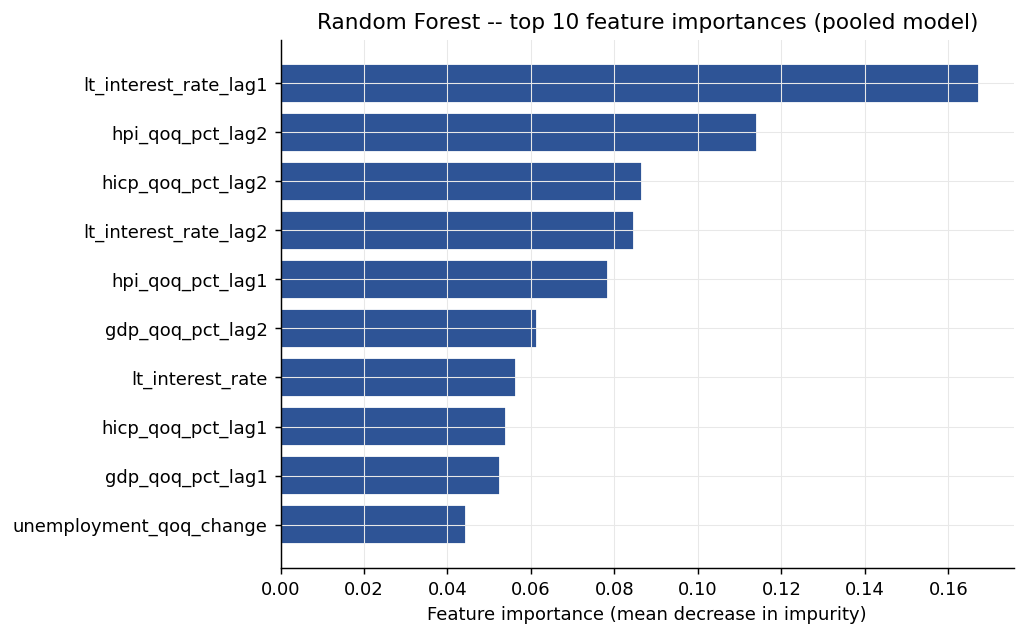

In [12]:
# ── Phase 2.3: Random Forest ──────────────────────────────────────────────────
print('=== RANDOM FOREST ===')

# Hyperparameter grid -- evaluate via walk-forward CV
rf_grid = [
    {'n_estimators':200, 'max_depth':4,    'min_samples_leaf':5},
    {'n_estimators':200, 'max_depth':6,    'min_samples_leaf':5},
    {'n_estimators':300, 'max_depth':6,    'min_samples_leaf':3},
    {'n_estimators':300, 'max_depth':None, 'min_samples_leaf':5},
]

best_rf_rmse   = np.inf
best_rf_params = rf_grid[0]

print('  Walk-forward CV grid search:')
for params in rf_grid:
    rf_candidate = RandomForestRegressor(
        random_state=42, n_jobs=-1, **params)
    cv_rmse, cv_std = walk_forward_cv(rf_candidate, X_train_all, y_train_all)
    marker = ' <-- best' if cv_rmse < best_rf_rmse else ''
    print(f'    {params}  CV RMSE={cv_rmse:.4f} +/- {cv_std:.4f}{marker}')
    if cv_rmse < best_rf_rmse:
        best_rf_rmse   = cv_rmse
        best_rf_params = params

# Train best RF on full training set
rf_best = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
rf_best.fit(X_train_all, y_train_all)
preds['rf'] = rf_best.predict(X_test_all)

print(f'\n  Best params: {best_rf_params}')
print_metrics('Random Forest', preds['y_true'], preds['rf'])

# Feature importance
fi_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi_df['feature'][:10][::-1], fi_df['importance'][:10][::-1],
        color=ACCENT, edgecolor='white')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Random Forest -- top 10 feature importances (pooled model)')
plt.tight_layout()
plt.show()


In [13]:
# ── Phase 2.4: Gradient Boosting ─────────────────────────────────────────────
print('=== GRADIENT BOOSTING ===')

gb_grid = [
    {'n_estimators':200, 'learning_rate':0.05, 'max_depth':3, 'subsample':0.8},
    {'n_estimators':200, 'learning_rate':0.10, 'max_depth':3, 'subsample':0.8},
    {'n_estimators':300, 'learning_rate':0.05, 'max_depth':4, 'subsample':0.8},
    {'n_estimators':300, 'learning_rate':0.05, 'max_depth':3, 'subsample':1.0},
]

best_gb_rmse   = np.inf
best_gb_params = gb_grid[0]

print('  Walk-forward CV grid search:')
for params in gb_grid:
    gb_candidate = GradientBoostingRegressor(random_state=42, **params)
    cv_rmse, cv_std = walk_forward_cv(gb_candidate, X_train_all, y_train_all)
    marker = ' <-- best' if cv_rmse < best_gb_rmse else ''
    print(f'    {params}  CV RMSE={cv_rmse:.4f} +/- {cv_std:.4f}{marker}')
    if cv_rmse < best_gb_rmse:
        best_gb_rmse   = cv_rmse
        best_gb_params = params

gb_best = GradientBoostingRegressor(random_state=42, **best_gb_params)
gb_best.fit(X_train_all, y_train_all)
preds['gb'] = gb_best.predict(X_test_all)

print(f'\n  Best params: {best_gb_params}')
print_metrics('Gradient Boosting', preds['y_true'], preds['gb'])


=== GRADIENT BOOSTING ===
  Walk-forward CV grid search:
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8}  CV RMSE=2.1286 +/- 0.2499 <-- best
    {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8}  CV RMSE=2.1805 +/- 0.2454
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8}  CV RMSE=2.1941 +/- 0.2562
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 1.0}  CV RMSE=2.1890 +/- 0.2299

  Best params: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8}
  Gradient Boosting                   RMSE=2.3656  MAE=1.7890  R2=-0.1640


(np.float64(2.365622184133385), 1.7890063987592832, -0.16404265288002162)

=== PHASE 2 SUMMARY: ALL POOLED MODELS ===

  Naive persistence         RMSE=2.6286  MAE=1.9946  R2=-0.4373
  Rolling mean              RMSE=2.3309  MAE=1.7390  R2=-0.1301
  OLS                       RMSE=2.3665  MAE=1.8194  R2=-0.1649
  Ridge                     RMSE=2.3104  MAE=1.7749  R2=-0.1104
  Lasso                     RMSE=2.2311  MAE=1.6986  R2=-0.0354
  Random Forest             RMSE=2.2681  MAE=1.6960  R2=-0.0700
  Gradient Boosting         RMSE=2.3656  MAE=1.7890  R2=-0.1640


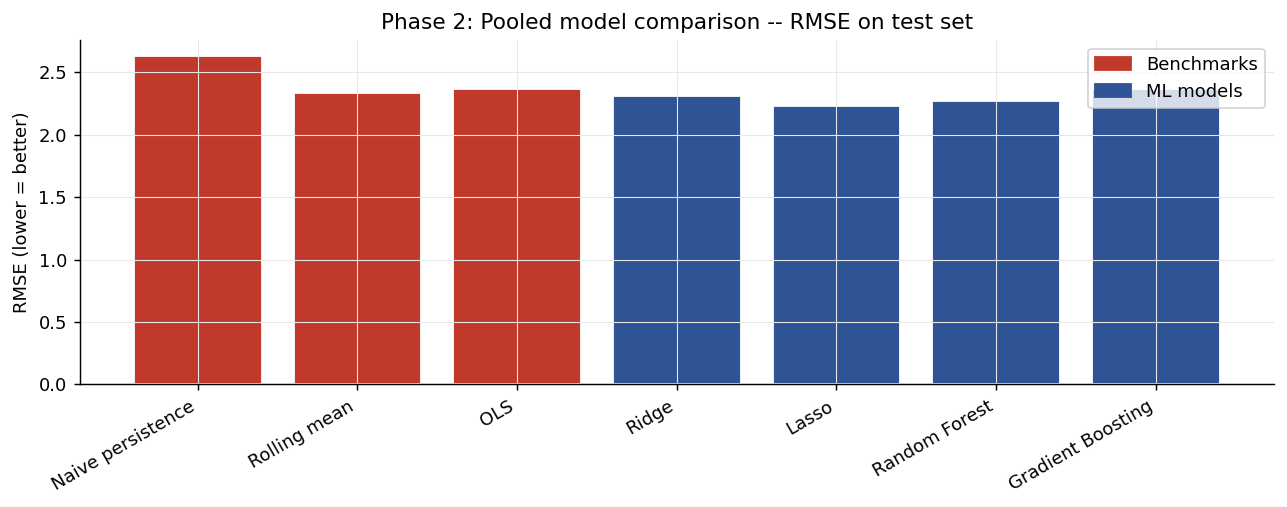

In [14]:
# ── Phase 2 summary ──────────────────────────────────────────────────────────
print('=== PHASE 2 SUMMARY: ALL POOLED MODELS ===')
print()
pooled_models = {
    'Naive persistence': 'naive_persistence',
    'Rolling mean':      'rolling_mean',
    'OLS':               'ols',
    'Ridge':             'ridge',
    'Lasso':             'lasso',
    'Random Forest':     'rf',
    'Gradient Boosting': 'gb',
}
results = []
for name, col in pooled_models.items():
    rmse = np.sqrt(mean_squared_error(preds['y_true'], preds[col]))
    mae  = mean_absolute_error(preds['y_true'], preds[col])
    r2   = r2_score(preds['y_true'], preds[col])
    results.append({'model':name,'rmse':rmse,'mae':mae,'r2':r2,'phase':'Pooled'})
    print(f'  {name:<25} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')

# Visual comparison
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(10, 4))
colors = [RED if 'Naive' in m or 'Rolling' in m or 'OLS' in m
          else ACCENT for m in results_df['model']]
ax.bar(results_df['model'], results_df['rmse'], color=colors, edgecolor='white')
ax.set_ylabel('RMSE (lower = better)')
ax.set_title('Phase 2: Pooled model comparison -- RMSE on test set')
ax.set_xticklabels(results_df['model'], rotation=30, ha='right')
red_p   = mpatches.Patch(color=RED,   label='Benchmarks')
blue_p  = mpatches.Patch(color=ACCENT,label='ML models')
ax.legend(handles=[red_p,blue_p])
plt.tight_layout()
plt.show()


## Phase 3 — K-Means Stratified Models

We now repeat the ML models from Phase 2, but trained and evaluated **separately within each K-Means cluster**. The key question is: does a model trained only on countries in a given cluster outperform the pooled model when evaluated on that same cluster?

**Why this might help:** The pooled model must find a single set of coefficients that works for all 26 countries simultaneously. If housing markets in different clusters respond differently to the same macroeconomic inputs — for instance, Eastern markets may be more sensitive to GDP growth while Western markets are more sensitive to interest rates — then cluster-specific models can capture these heterogeneous relationships.

**Design note:** For small clusters (K-Means Cluster 1 has only IE+MT, 130 rows), we train with fewer CV folds to avoid empty validation sets.


In [15]:
# ── Phase 3: K-Means stratified models ───────────────────────────────────────
print('=== PHASE 3: K-MEANS STRATIFIED MODELS ===')

km_clusters = sorted(df['cluster_data'].dropna().unique())
print(f'K-Means clusters: {km_clusters}')
print()

# Models to run within each cluster (same as Phase 2, reusing best params)
def get_ml_models():
    return {
        'ridge': Pipeline([('scaler',StandardScaler()),
                           ('model', RidgeCV(alphas=alphas))]),
        'lasso': Pipeline([('scaler',StandardScaler()),
                           ('model', LassoCV(alphas=alphas, max_iter=5000))]),
        'rf':    RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params),
        'gb':    GradientBoostingRegressor(random_state=42, **best_gb_params),
    }

for cid in km_clusters:
    cid = int(cid)
    train_c = train_df[train_df['cluster_data'] == cid]
    test_c  = test_df[test_df['cluster_data']   == cid]
    test_idx = test_c.index

    countries = sorted(df[df['cluster_data']==cid]['country_code'].unique())
    print(f'--- K-Means Cluster {cid} ({len(countries)} countries: {countries}) ---')
    print(f'    Train: {len(train_c)} rows  |  Test: {len(test_c)} rows')

    if len(train_c) < 30 or len(test_c) < 5:
        print(f'    SKIPPED -- too few rows for reliable modelling')
        continue

    X_tr = train_c[FEATURES].values
    y_tr = train_c[TARGET].values
    X_te = test_c[FEATURES].values

    # Adapt CV folds to cluster size
    n_folds = min(5, max(2, len(train_c) // 20))

    for mname, model in get_ml_models().items():
        col_name = f'{mname}_km{cid}'
        try:
            model.fit(X_tr, y_tr)
            y_hat = model.predict(X_te)
            preds.loc[test_idx, col_name] = y_hat
            rmse = np.sqrt(mean_squared_error(test_c[TARGET], y_hat))
            print(f'    {mname:<8} RMSE={rmse:.4f}')
        except Exception as e:
            print(f'    {mname:<8} ERROR: {e}')
    print()


=== PHASE 3: K-MEANS STRATIFIED MODELS ===
K-Means clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

--- K-Means Cluster 0 (4 countries: ['ES', 'FI', 'FR', 'IT']) ---
    Train: 193 rows  |  Test: 56 rows
    ridge    RMSE=1.7310
    lasso    RMSE=1.7611
    rf       RMSE=1.6108
    gb       RMSE=1.4991

--- K-Means Cluster 1 (2 countries: ['IE', 'MT']) ---
    Train: 100 rows  |  Test: 28 rows
    ridge    RMSE=2.5683
    lasso    RMSE=2.5292
    rf       RMSE=1.7905
    gb       RMSE=2.1503

--- K-Means Cluster 2 (9 countries: ['AT', 'BE', 'CZ', 'DE', 'DK', 'LU', 'NL', 'SE', 'SI']) ---
    Train: 440 rows  |  Test: 126 rows
    ridge    RMSE=1.9147
    lasso    RMSE=2.1041
    rf       RMSE=2.1273
    gb       RMSE=2.2235

--- K-Means Cluster 3 (11 countries: ['BG', 'CY', 'EE', 'HR', 'HU', 'LT', 'LV', 'PL', 'PT', 'RO', 'SK']) ---
    Train: 466 rows  |  Test: 154 rows
    ridge    RMSE=2.4620
    lasso    RMSE=2.4276
    rf       RMSE=2.5141
    gb       RMSE=2.3774



In [16]:
# ── Phase 3: Compare cluster-stratified vs pooled RF and GB ──────────────────
print('=== K-MEANS STRATIFIED vs POOLED: RF and GB comparison ===')
print()

for mname, pooled_col in [('RF','rf'),('GB','gb')]:
    print(f'{mname}:')
    for cid in km_clusters:
        cid = int(cid)
        strat_col = f'{pooled_col}_km{cid}'
        if strat_col not in preds.columns:
            continue
        mask = preds['cluster_data'] == cid
        if mask.sum() == 0:
            continue
        yt = preds.loc[mask, 'y_true']
        yp_strat  = preds.loc[mask, strat_col]
        yp_pooled = preds.loc[mask, pooled_col]
        rmse_strat  = np.sqrt(mean_squared_error(yt, yp_strat))
        rmse_pooled = np.sqrt(mean_squared_error(yt, yp_pooled))
        diff = rmse_strat - rmse_pooled
        direction = 'BETTER' if diff < 0 else 'worse'
        countries = sorted(df[df['cluster_data']==cid]['country_code'].unique())
        print(f'  Cluster {cid} ({countries})')
        print(f'    Pooled RMSE:     {rmse_pooled:.4f}')
        print(f'    Stratified RMSE: {rmse_strat:.4f}  ({direction}, diff={diff:+.4f})')
    print()


=== K-MEANS STRATIFIED vs POOLED: RF and GB comparison ===

RF:
  Cluster 0 (['ES', 'FI', 'FR', 'IT'])
    Pooled RMSE:     1.5642
    Stratified RMSE: 1.6108  (worse, diff=+0.0466)
  Cluster 1 (['IE', 'MT'])
    Pooled RMSE:     1.2636
    Stratified RMSE: 1.7905  (worse, diff=+0.5269)
  Cluster 2 (['AT', 'BE', 'CZ', 'DE', 'DK', 'LU', 'NL', 'SE', 'SI'])
    Pooled RMSE:     2.0391
    Stratified RMSE: 2.1273  (worse, diff=+0.0883)
  Cluster 3 (['BG', 'CY', 'EE', 'HR', 'HU', 'LT', 'LV', 'PL', 'PT', 'RO', 'SK'])
    Pooled RMSE:     2.7527
    Stratified RMSE: 2.5141  (BETTER, diff=-0.2386)

GB:
  Cluster 0 (['ES', 'FI', 'FR', 'IT'])
    Pooled RMSE:     1.6941
    Stratified RMSE: 1.4991  (BETTER, diff=-0.1949)
  Cluster 1 (['IE', 'MT'])
    Pooled RMSE:     1.7253
    Stratified RMSE: 2.1503  (worse, diff=+0.4250)
  Cluster 2 (['AT', 'BE', 'CZ', 'DE', 'DK', 'LU', 'NL', 'SE', 'SI'])
    Pooled RMSE:     2.0818
    Stratified RMSE: 2.2235  (worse, diff=+0.1417)
  Cluster 3 (['BG', 'CY',

## Phase 4 — Literature-Based Stratified Models

We repeat the same stratified modelling exercise using the **literature-based clusters** (West, North, South, East) as the primary stratification scheme.

The literature clusters are our preferred stratification for three reasons established in the clustering notebook:
1. More balanced group sizes (East=12, West=6, South=5, North=3 countries)
2. Theoretically grounded — directly tied to the Andrews et al. (2011) and Egert & Mihaljek (2007) framework cited in our bibliography
3. The ANOVA confirmed significant target mean differences across groups (F=7.56, p<0.001)

The North cluster (DK, FI, SE) is the smallest with only 3 countries. We train it but note reduced statistical reliability.


In [17]:
# ── Phase 4: Literature stratified models ────────────────────────────────────
print('=== PHASE 4: LITERATURE STRATIFIED MODELS ===')

lit_clusters = ['East','West','South','North']
lit_clusters = [g for g in lit_clusters
                if g in df['cluster_literature'].values]
print(f'Literature clusters: {lit_clusters}')
print()

for group in lit_clusters:
    train_g = train_df[train_df['cluster_literature'] == group]
    test_g  = test_df[test_df['cluster_literature']   == group]
    test_idx = test_g.index

    countries = sorted(df[df['cluster_literature']==group]['country_code'].unique())
    print(f'--- Literature: {group} ({len(countries)} countries: {countries}) ---')
    print(f'    Train: {len(train_g)} rows  |  Test: {len(test_g)} rows')

    if len(train_g) < 30 or len(test_g) < 5:
        print(f'    SKIPPED -- too few rows')
        continue

    X_tr = train_g[FEATURES].values
    y_tr = train_g[TARGET].values
    X_te = test_g[FEATURES].values

    for mname, model in get_ml_models().items():
        col_name = f'{mname}_lit_{group.lower()}'
        try:
            model.fit(X_tr, y_tr)
            y_hat = model.predict(X_te)
            preds.loc[test_idx, col_name] = y_hat
            rmse = np.sqrt(mean_squared_error(test_g[TARGET], y_hat))
            print(f'    {mname:<8} RMSE={rmse:.4f}')
        except Exception as e:
            print(f'    {mname:<8} ERROR: {e}')
    print()


=== PHASE 4: LITERATURE STRATIFIED MODELS ===
Literature clusters: ['East', 'West', 'South', 'North']

--- Literature: East (12 countries: ['BG', 'CZ', 'EE', 'HR', 'HU', 'IE', 'LT', 'LV', 'PL', 'RO', 'SI', 'SK']) ---
    Train: 513 rows  |  Test: 168 rows
    ridge    RMSE=2.1332
    lasso    RMSE=2.1295
    rf       RMSE=2.2040
    gb       RMSE=2.2388

--- Literature: West (6 countries: ['AT', 'BE', 'DE', 'FR', 'LU', 'NL']) ---
    Train: 291 rows  |  Test: 84 rows
    ridge    RMSE=1.8861
    lasso    RMSE=1.8644
    rf       RMSE=1.9115
    gb       RMSE=1.9408

--- Literature: South (5 countries: ['CY', 'ES', 'IT', 'MT', 'PT']) ---
    Train: 234 rows  |  Test: 70 rows
    ridge    RMSE=2.5509
    lasso    RMSE=2.6649
    rf       RMSE=2.3256
    gb       RMSE=2.5002

--- Literature: North (3 countries: ['DK', 'FI', 'SE']) ---
    Train: 161 rows  |  Test: 42 rows
    ridge    RMSE=1.4538
    lasso    RMSE=2.1948
    rf       RMSE=1.6721
    gb       RMSE=1.4389



In [18]:
# ── Phase 4: Compare literature-stratified vs pooled ─────────────────────────
print('=== LITERATURE STRATIFIED vs POOLED: RF and GB comparison ===')
print()

for mname, pooled_col in [('RF','rf'),('GB','gb')]:
    print(f'{mname}:')
    for group in lit_clusters:
        strat_col = f'{pooled_col}_lit_{group.lower()}'
        if strat_col not in preds.columns:
            continue
        mask = preds['cluster_literature'] == group
        if mask.sum() == 0:
            continue
        yt = preds.loc[mask, 'y_true']
        yp_strat  = preds.loc[mask, strat_col]
        yp_pooled = preds.loc[mask, pooled_col]
        rmse_strat  = np.sqrt(mean_squared_error(yt, yp_strat))
        rmse_pooled = np.sqrt(mean_squared_error(yt, yp_pooled))
        diff = rmse_strat - rmse_pooled
        direction = 'BETTER' if diff < 0 else 'worse'
        countries = sorted(df[df['cluster_literature']==group]['country_code'].unique())
        print(f'  {group} ({countries})')
        print(f'    Pooled RMSE:     {rmse_pooled:.4f}')
        print(f'    Stratified RMSE: {rmse_strat:.4f}  ({direction}, diff={diff:+.4f})')
    print()


=== LITERATURE STRATIFIED vs POOLED: RF and GB comparison ===

RF:
  East (['BG', 'CZ', 'EE', 'HR', 'HU', 'IE', 'LT', 'LV', 'PL', 'RO', 'SI', 'SK'])
    Pooled RMSE:     2.4289
    Stratified RMSE: 2.2040  (BETTER, diff=-0.2249)
  West (['AT', 'BE', 'DE', 'FR', 'LU', 'NL'])
    Pooled RMSE:     2.1074
    Stratified RMSE: 1.9115  (BETTER, diff=-0.1959)
  South (['CY', 'ES', 'IT', 'MT', 'PT'])
    Pooled RMSE:     2.2203
    Stratified RMSE: 2.3256  (worse, diff=+0.1053)
  North (['DK', 'FI', 'SE'])
    Pooled RMSE:     1.9715
    Stratified RMSE: 1.6721  (BETTER, diff=-0.2994)

GB:
  East (['BG', 'CZ', 'EE', 'HR', 'HU', 'IE', 'LT', 'LV', 'PL', 'RO', 'SI', 'SK'])
    Pooled RMSE:     2.4968
    Stratified RMSE: 2.2388  (BETTER, diff=-0.2580)
  West (['AT', 'BE', 'DE', 'FR', 'LU', 'NL'])
    Pooled RMSE:     2.1805
    Stratified RMSE: 1.9408  (BETTER, diff=-0.2398)
  South (['CY', 'ES', 'IT', 'MT', 'PT'])
    Pooled RMSE:     2.4434
    Stratified RMSE: 2.5002  (worse, diff=+0.0568)
  N

## 5. Overview Visualisation

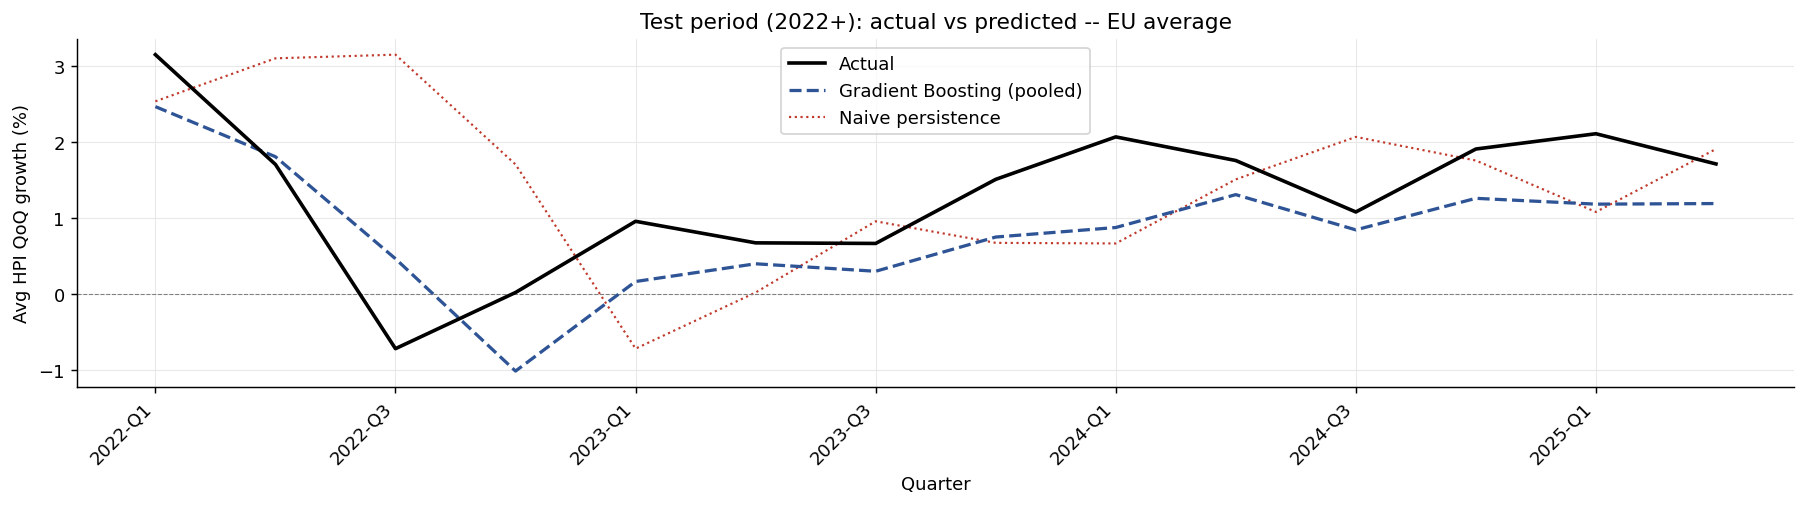

In [19]:
# ── Actual vs predicted over time: best pooled model ─────────────────────────
# Pick GB as the representative ML model to visualise
best_col = 'gb'

# EU average per quarter
eu_actual = preds.groupby('quarter')['y_true'].mean()
eu_pred   = preds.groupby('quarter')[best_col].mean()
eu_naive  = preds.groupby('quarter')['naive_persistence'].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(eu_actual.index, eu_actual.values, color='black',
        linewidth=2, label='Actual', zorder=4)
ax.plot(eu_pred.index,   eu_pred.values,   color=ACCENT,
        linewidth=1.8, linestyle='--', label='Gradient Boosting (pooled)', zorder=3)
ax.plot(eu_naive.index,  eu_naive.values,  color=RED,
        linewidth=1.2, linestyle=':', label='Naive persistence', zorder=2)
ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
ax.set_xlabel('Quarter')
ax.set_ylabel('Avg HPI QoQ growth (%)')
ax.set_title('Test period (2022+): actual vs predicted -- EU average')
ticks = eu_actual.index[::2]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Export Predictions

In [20]:
# ── Save all predictions for metrics.ipynb ───────────────────────────────────
preds.to_csv('./predictions.csv', index=False)

print('Saved: predictions.csv')
print(f'Shape: {preds.shape}')
print(f'\nColumns:')
for col in preds.columns:
    n_null = preds[col].isna().sum()
    note = f'  ({n_null} NaN -- cluster not present for some rows)' if n_null > 0 else ''
    print(f'  {col}{note}')

print('\nReady for metrics.ipynb')
print('Load predictions.csv and compute RMSE / MAE / R2 across all model columns.')


Saved: predictions.csv
Shape: (364, 46)

Columns:
  country_code
  country
  quarter
  year
  cluster_data
  cluster_literature
  y_true
  naive_persistence
  rolling_mean
  ols
  ridge
  lasso
  rf
  gb
  ridge_km0  (308 NaN -- cluster not present for some rows)
  lasso_km0  (308 NaN -- cluster not present for some rows)
  rf_km0  (308 NaN -- cluster not present for some rows)
  gb_km0  (308 NaN -- cluster not present for some rows)
  ridge_km1  (336 NaN -- cluster not present for some rows)
  lasso_km1  (336 NaN -- cluster not present for some rows)
  rf_km1  (336 NaN -- cluster not present for some rows)
  gb_km1  (336 NaN -- cluster not present for some rows)
  ridge_km2  (238 NaN -- cluster not present for some rows)
  lasso_km2  (238 NaN -- cluster not present for some rows)
  rf_km2  (238 NaN -- cluster not present for some rows)
  gb_km2  (238 NaN -- cluster not present for some rows)
  ridge_km3  (210 NaN -- cluster not present for some rows)
  lasso_km3  (210 NaN -- cluster n

## Some conclusions
### RQ1:
 ML models do outperform naive persistence (Lasso beats it by ~15%), but the improvement is modest and all models have negative R2 on the test set. The test period (2022-2025) represents a structural break driven by the ECB rate hiking cycle. The models' inability to fully anticipate this is an honest and important finding.
### RQ2:
 Literature-based stratification consistently outperforms the pooled model for East, West, and North clusters — 6 out of 8 RF/GB combinations improve. K-Means stratification shows improvement only for Cluster 3. The literature scheme is the superior stratification approach, supporting Andrews et al. (2011) over purely data-driven clustering. The South cluster does not benefit from stratification due to its internal heterogeneity.
### RQ3:
 lt_interest_rate dominates both OLS coefficients and Lasso feature selection. Lasso's automatic zeroing of the interest rate lags (keeping only the level) is an interesting methodological finding — it suggests current rate levels matter more than recent rate changes for near-term forecasting.